In [1]:
import torch

In [2]:
a = torch.linspace(-1,1,10)
print(a)
print(a.shape)

tensor([-1.0000, -0.7778, -0.5556, -0.3333, -0.1111,  0.1111,  0.3333,  0.5556,
         0.7778,  1.0000])
torch.Size([10])


In [3]:
#size가 1인 dimension추가
#dim=추가할 인덱스(0, 추가할 인덱스)
#unsqueeze ->차원증가
b = torch.unsqueeze(torch.linspace(-1,1,10), dim=1)
print(b)
print(b.shape)

tensor([[-1.0000],
        [-0.7778],
        [-0.5556],
        [-0.3333],
        [-0.1111],
        [ 0.1111],
        [ 0.3333],
        [ 0.5556],
        [ 0.7778],
        [ 1.0000]])
torch.Size([10, 1])


In [4]:
#size가 1인 dimension 제거
print(b.shape)
print(torch.squeeze(b))
print(torch.squeeze(b).shape)

torch.Size([10, 1])
tensor([-1.0000, -0.7778, -0.5556, -0.3333, -0.1111,  0.1111,  0.3333,  0.5556,
         0.7778,  1.0000])
torch.Size([10])


torch.Size([100, 1])
torch.Size([100, 1])


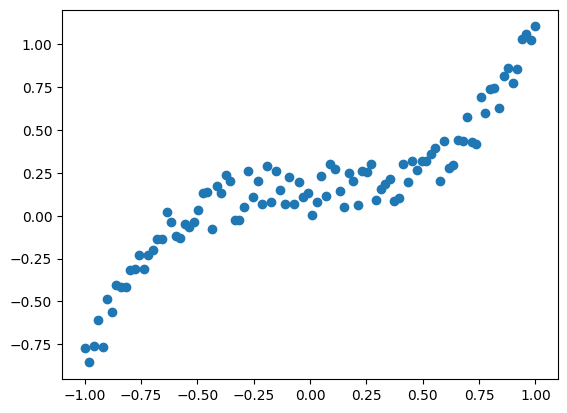

In [5]:
import random
from matplotlib import pyplot as plt
random.seed(1)
torch.manual_seed(1)
X = torch.unsqueeze(torch.linspace(-1,1,100), dim=1)
y = X.pow(3) + 0.3 *torch.rand(X.size())
print(X.shape)
print(y.shape)
plt.scatter(X.numpy(), y.numpy())

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [7]:
from torch import nn
learning_rate = 1e-3
model = nn.Sequential(
    nn.Linear(1,100),
    nn.Linear(100,10),
    nn.Linear(10,1)
)

In [8]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
for t in range(1000):
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train) #오차계산
    print(f'epoch: {t}, loss: {loss:.3f}')
    optimizer.zero_grad() #기울기 초기화
    loss.backward() #역전파 계산
    optimizer.step() #파라미터 업데이트

epoch: 0, loss: 0.170
epoch: 1, loss: 0.166
epoch: 2, loss: 0.163
epoch: 3, loss: 0.159
epoch: 4, loss: 0.155
epoch: 5, loss: 0.152
epoch: 6, loss: 0.148
epoch: 7, loss: 0.145
epoch: 8, loss: 0.142
epoch: 9, loss: 0.139
epoch: 10, loss: 0.136
epoch: 11, loss: 0.133
epoch: 12, loss: 0.130
epoch: 13, loss: 0.128
epoch: 14, loss: 0.125
epoch: 15, loss: 0.123
epoch: 16, loss: 0.120
epoch: 17, loss: 0.118
epoch: 18, loss: 0.116
epoch: 19, loss: 0.113
epoch: 20, loss: 0.111
epoch: 21, loss: 0.109
epoch: 22, loss: 0.107
epoch: 23, loss: 0.105
epoch: 24, loss: 0.103
epoch: 25, loss: 0.102
epoch: 26, loss: 0.100
epoch: 27, loss: 0.098
epoch: 28, loss: 0.097
epoch: 29, loss: 0.095
epoch: 30, loss: 0.093
epoch: 31, loss: 0.092
epoch: 32, loss: 0.091
epoch: 33, loss: 0.089
epoch: 34, loss: 0.088
epoch: 35, loss: 0.086
epoch: 36, loss: 0.085
epoch: 37, loss: 0.084
epoch: 38, loss: 0.083
epoch: 39, loss: 0.081
epoch: 40, loss: 0.080
epoch: 41, loss: 0.079
epoch: 42, loss: 0.078
epoch: 43, loss: 0.07

In [9]:
#9개의 모형 테스트
learning_rate = 1e-3
n_networks = 9
models = list()
criterion = torch.nn.MSELoss()
for i in range(n_networks):
    model = nn.Sequential(
        nn.Linear(1,100),
        #나머지 값에 따라 relu, sigmoid, tanh 배정
        nn.ReLU() if i % 3 == 0 else nn.Tanh() if i % 3 == 1 else nn.Sigmoid(),
        nn.Linear(100,1)
    )
    models.append(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for t in range(1000):
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        print(f'model: {i+1}, epoch: {t}, loss: {loss.item():.3f}')
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


model: 1, epoch: 0, loss: 0.204
model: 1, epoch: 1, loss: 0.185
model: 1, epoch: 2, loss: 0.168
model: 1, epoch: 3, loss: 0.151
model: 1, epoch: 4, loss: 0.136
model: 1, epoch: 5, loss: 0.122
model: 1, epoch: 6, loss: 0.110
model: 1, epoch: 7, loss: 0.098
model: 1, epoch: 8, loss: 0.088
model: 1, epoch: 9, loss: 0.079
model: 1, epoch: 10, loss: 0.071
model: 1, epoch: 11, loss: 0.064
model: 1, epoch: 12, loss: 0.058
model: 1, epoch: 13, loss: 0.053
model: 1, epoch: 14, loss: 0.048
model: 1, epoch: 15, loss: 0.045
model: 1, epoch: 16, loss: 0.042
model: 1, epoch: 17, loss: 0.039
model: 1, epoch: 18, loss: 0.037
model: 1, epoch: 19, loss: 0.036
model: 1, epoch: 20, loss: 0.034
model: 1, epoch: 21, loss: 0.033
model: 1, epoch: 22, loss: 0.033
model: 1, epoch: 23, loss: 0.032
model: 1, epoch: 24, loss: 0.032
model: 1, epoch: 25, loss: 0.031
model: 1, epoch: 26, loss: 0.031
model: 1, epoch: 27, loss: 0.031
model: 1, epoch: 28, loss: 0.031
model: 1, epoch: 29, loss: 0.031
model: 1, epoch: 30,

In [10]:
acc=[]
for model in models:
    mse = ((torch.pow((model(X_test).data - y_test), 2)).sum()) / len(y_test)
    acc.append(mse)
    print(mse)

tensor(0.0079)
tensor(0.0092)
tensor(0.0239)
tensor(0.0079)
tensor(0.0085)
tensor(0.0245)
tensor(0.0078)
tensor(0.0084)
tensor(0.0241)


In [11]:
for i in range(9):
    model=models[i]
    print(model)
    print(acc[i])

Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=1, bias=True)
)
tensor(0.0079)
Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=1, bias=True)
)
tensor(0.0092)
Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=100, out_features=1, bias=True)
)
tensor(0.0239)
Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=1, bias=True)
)
tensor(0.0079)
Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): Tanh()
  (2): Linear(in_features=100, out_features=1, bias=True)
)
tensor(0.0085)
Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=100, out_features=1, bias=True)
)
tensor(0.0245)
Sequential(
  (0): Linear(in_features=1,

In [12]:
import numpy as np
model = models[np.argmin(acc)]
print(model)
print(np.argmin(acc))
print(acc[np.argmin(acc)])

Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=1, bias=True)
)
6
tensor(0.0078)


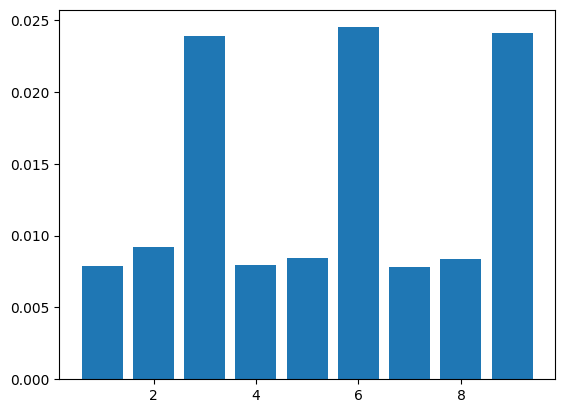

In [13]:
plt.bar(range(1,10),acc)
plt.show()

In [14]:
from torchinfo import summary
summary(model)
summary(model, input_size=(32,1))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 1]                   --
├─Linear: 1-1                            [32, 100]                 200
├─ReLU: 1-2                              [32, 100]                 --
├─Linear: 1-3                            [32, 1]                   101
Total params: 301
Trainable params: 301
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.00
Estimated Total Size (MB): 0.03

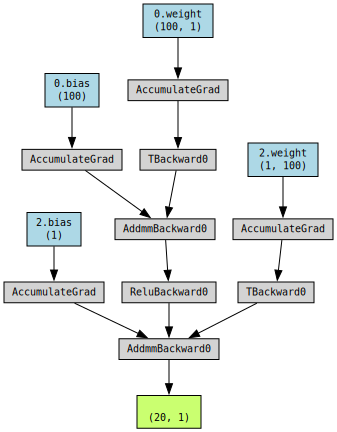

In [15]:
from torchviz import make_dot
pred=model(X_test)
make_dot(pred, params=dict(model.named_parameters()))


(process:5944): Pango-WARNING **: 14:50:46.808: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


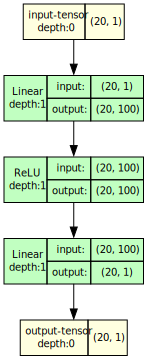

In [16]:
from torchview import draw_graph
model_graph = draw_graph(model, input_data=X_test)
model_graph.visual_graph

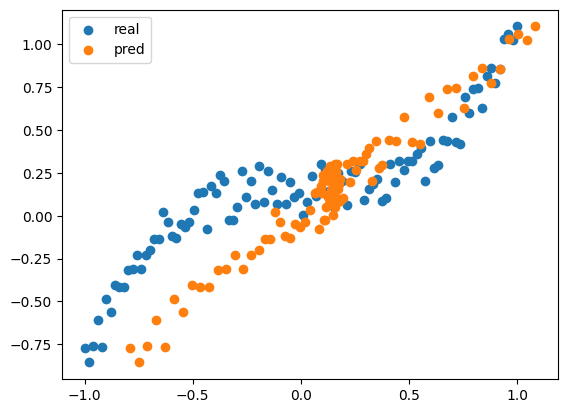

In [17]:
plt.scatter(X.numpy(), y.numpy(), label='real')
#detach() 역전파를 중단 ->이미 학습된 모델이므로 순전파만 진행
plt.scatter(model(X).detach().numpy(), y.numpy(), label='pred')
plt.legend()
plt.show()